# CT Scan Classification Notebook

This notebook trains, evaluates, compares, and saves multiple CT scan image classifiers:

1. a small baseline CNN, used as a simple reference model;
2. a ResNet18-style model trained from scratch, used as the stronger comparison model.

The workflow is: load data, inspect class balance, train a model, evaluate it on the test set, generate Grad-CAM explanations, and save the final results.


The main comparison focus is medical reliability: macro F1, macro recall, per-class recall, and the minimum class recall are more important than accuracy alone.


## 0. Notebook Setup

This cell only keeps the notebook output easier to read by suppressing non-critical warnings.


In [3]:
# Keep notebook output focused by hiding non-critical warnings.
import warnings

warnings.filterwarnings("ignore")


## 1. Load the CT Scan Dataset

The dataset is expected to use one folder per class inside `data/train`, `data/valid`, and `data/test`. The custom `CTScanFolderDataset` reads those folders, converts images to RGB, applies the selected transform, and returns a dictionary with `image`, `label`, and `path`.

Training images use light augmentation. Validation and test images only use resizing, tensor conversion, and normalization so evaluation stays deterministic.


In [4]:
from src.data.data import CTScanFolderDataset
from src.transforms.ct_transforms import get_train_transforms, get_eval_transforms

IMAGE_SIZE = 224

# Training uses light augmentation. Validation and test use deterministic preprocessing.
train_transform = get_train_transforms(IMAGE_SIZE)
eval_transform = get_eval_transforms(IMAGE_SIZE)

trainDataSet = CTScanFolderDataset("data/train", train_transform)
validDataSet = CTScanFolderDataset("data/valid", eval_transform)
testDataSet = CTScanFolderDataset("data/test", eval_transform)

print("Number of train samples:", len(trainDataSet))
print("Number of validation samples:", len(validDataSet))
print("Number of test samples:", len(testDataSet))

print("Classes:", trainDataSet.classes)
print("Class-to-index mapping:", trainDataSet.class_to_idx)

sample = trainDataSet[0]
print("Sample image tensor shape:", sample["image"].shape)
print("Sample label index:", sample["label"])


Number of train samples: 613
Number of validation samples: 72
Number of test samples: 315
Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Class-to-index mapping: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}
Sample image tensor shape: torch.Size([3, 224, 224])
Sample label index: 0


## 2. Visual Sanity Check

Before training, display one transformed image from each class. This helps catch folder mistakes, broken images, or transforms that make the CT scans look unrealistic.


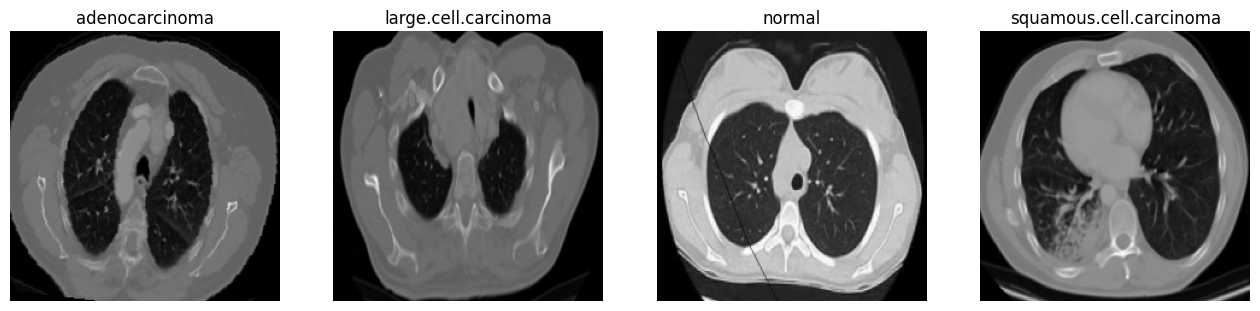

In [5]:
from src.plot.plot import plot_one_image_per_class

# Quick visual check: one transformed training image from each class.
plot_one_image_per_class(trainDataSet)


## 3. Create DataLoaders

DataLoaders group samples into mini-batches. The training loader shuffles data, while validation and test loaders keep a stable order.


In [6]:
from src.data.dataLoader import create_dataloaders
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

BATCH_SIZE = 32

train_loader, valid_loader, test_loader, classes = create_dataloaders(
    train_dir="data/train",
    valid_dir="data/valid",
    test_dir="data/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0
)

# =========================
# WeightedRandomSampler
# =========================

train_labels = []

for i in range(len(train_loader.dataset)):
    sample = train_loader.dataset[i]
    train_labels.append(sample["label"])

class_counts = Counter(train_labels)
print("Class counts:", class_counts)

sample_weights = [
    1.0 / class_counts[label]
    for label in train_labels
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

balanced_train_loader = DataLoader(
    train_loader.dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False,
    num_workers=0
)

# Check one batch
batch = next(iter(balanced_train_loader))
images = batch["image"]
labels = batch["label"]

print("Classes:", classes)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)
print("Balanced batch distribution:", Counter(labels.numpy()))


Class counts: Counter({0: 195, 3: 155, 2: 148, 1: 115})
Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([2, 1, 3, 2, 1, 0, 0, 3, 0, 1, 0, 1, 1, 3, 0, 1, 1, 1, 2, 0, 1, 2, 1, 3,
        0, 2, 3, 1, 2, 1, 1, 2])
Balanced batch distribution: Counter({np.int64(1): 13, np.int64(2): 7, np.int64(0): 7, np.int64(3): 5})


## 4. Check Class Imbalance

Medical datasets are often imbalanced. These plots show how many images each class has in each split. The training cells below use class-weighted cross entropy so minority classes receive more attention during optimization.


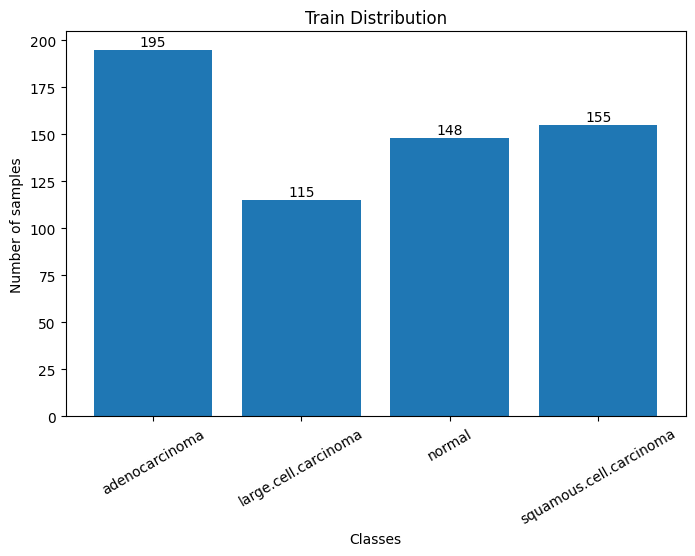

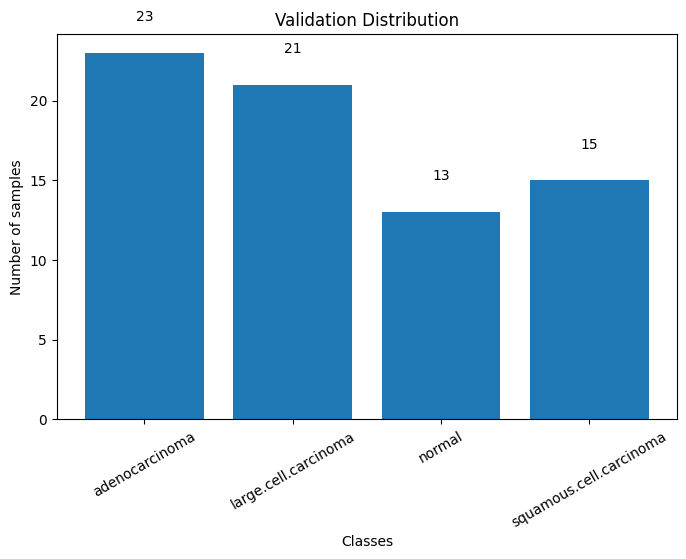

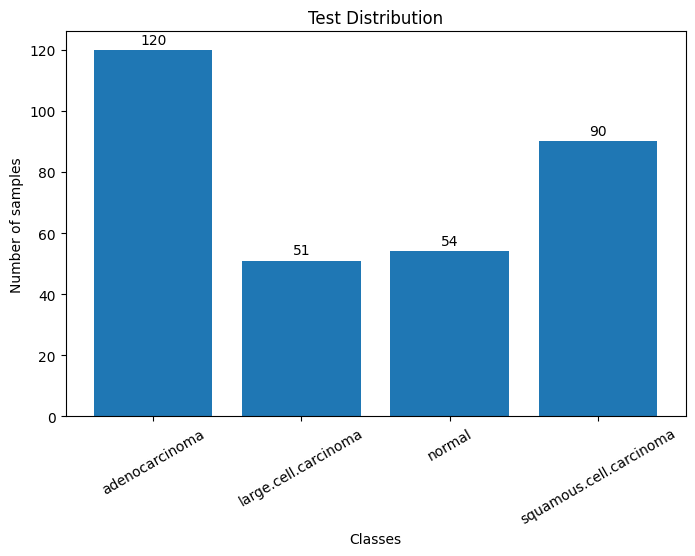

In [7]:
from src.plot.plot import plot_class_distribution

plot_class_distribution(trainDataSet, "Train Distribution")
plot_class_distribution(validDataSet, "Validation Distribution")
plot_class_distribution(testDataSet, "Test Distribution")



## 6. Train the Baseline CNN

The baseline model gives a simple reference point. If the larger ResNet does not improve over this model, that is a useful signal to inspect data quality, training settings, or overfitting.

The loss uses class weights computed from the training labels. Higher weights are assigned to underrepresented classes.


In [8]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim

from src.model.cnn_baseline import CNNBaseline
from src.training.training import train_one_epoch, validate_one_epoch
from src.loss.FocalLoss import FocalLoss

from src.plot.training_plots import save_training_history, save_training_curves

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CNNBaseline(
    num_classes=len(classes),
    dropout=0.5
).to(device)

# Since we use WeightedRandomSampler, start without class weights
criterion = FocalLoss(gamma=1.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

num_epochs = 50
patience = 5
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,  # IMPORTANT
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

model.load_state_dict(best_model_state)

save_dir = "results/baseline"

save_training_history(history, save_dir)
save_training_curves(history, save_dir)

print("\nCNNBaseline training with balanced sampler complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")

Using device: cpu

Epoch 1/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.17it/s]


Train Loss: 0.9379 | Train Acc: 0.3931
Valid Loss: 0.9689 | Valid Acc: 0.3611
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.38it/s]


Train Loss: 0.8331 | Train Acc: 0.5008
Valid Loss: 0.8096 | Valid Acc: 0.4167
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 3/50


...

Train Loss: 0.6304 | Train Acc: 0.5742
Valid Loss: 0.6678 | Valid Acc: 0.4722
Learning Rate: 0.000013
No improvement for 3/5 epochs.

Epoch 17/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.91it/s]


Train Loss: 0.6750 | Train Acc: 0.5498
Valid Loss: 0.6684 | Valid Acc: 0.5139
Learning Rate: 0.000013
No improvement for 4/5 epochs.

Epoch 18/50


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.50it/s]


Train Loss: 0.6182 | Train Acc: 0.5791
Valid Loss: 0.6698 | Valid Acc: 0.5139
Learning Rate: 0.000013
No improvement for 5/5 epochs.

Early stopping triggered.
Training history saved to: results/baseline\training_history.json
Training curve saved to: results/baseline\loss_curve.png
Training curve saved to: results/baseline\accuracy_curve.png

CNNBaseline training with balanced sampler complete.
Best epoch: 13
Best validation loss: 0.6583


## 8. Evaluate the Baseline CNN

Evaluation runs on the held-out test set. The metrics summarize classification quality, the confusion matrix shows which classes are confused, and Grad-CAM images highlight the image regions that influenced selected predictions.


In [9]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM saves visual explanations for a small set of test predictions.
    generate_gradcam=True,
    gradcam_save_dir="results/baseline/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nPer-Class Recall:\n")
for class_name, recall in metrics["per_class_recall"].items():
    print(f"{class_name}: {recall:.4f}")

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])


Evaluating: 100%|██████████| 10/10 [00:04<00:00,  2.25it/s]


Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Grad-CAM target layer selected: features.8
Accuracy: 0.42857142857142855
Precision Macro: 0.5876984126984127
Recall Macro: 0.5615196078431373
F1 Macro: 0.4801371974384022

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.36      0.08      0.14       120
   large.cell.carcinoma       0.22      0.86      0.35        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.77      0.30      0.43        90

               accuracy                           0.43       315
              macro avg       0.59      0.56      0.48       315
           weighted avg       0.56      0.43  

<!-- codex-explanation-cell -->

### Interpretation Guide: Baseline CNN

Use this result as the minimum standard for later models. If a larger model has higher accuracy but lower macro recall or a much weaker cancer-class recall, it is not necessarily better for this medical task.


## 9. Save Baseline Results

This saves the baseline metrics, configuration, and architecture outputs under `results/baseline`. Keeping the config beside the metrics makes the experiment easier to reproduce later.


In [10]:
from src.Save.save import save_evaluation_results

vgg16_config = {
    "model_name": "Baseline",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "best_epoch": best_epoch,
    "best_valid_loss": best_valid_loss,

    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    "loss_function": "FocalLoss",
    "focal_gamma": 1.0,

    "scheduler": "StepLR",
    "scheduler_step_size": 5,
    "scheduler_gamma": 0.5,

    "sampler": "WeightedRandomSampler",
    "balanced_training": True,

    "early_stopping": True,
    "patience": patience,
    "min_delta": min_delta,

    "dropout": 0.5,

    "class_names": classes,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225]
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # New metric
        "per_class_recall": metrics["per_class_recall"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },
    model=model,
    save_dir="results/baseline",
    config=vgg16_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("Baseline evaluation results saved successfully.")



(process:17748): Pango-WARNING **: 15:18:03.825: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/baseline\test_metrics.json
Model weights saved to: results/baseline\model.pth
Architecture image saved to: results/baseline\architecture.svg
Baseline evaluation results saved successfully.


## 10. Train ResNet18 From Scratch

This section trains a deeper ResNet18-style model without pretrained weights. It uses the same data, class-weighted loss, and optimizer family as the baseline so the comparison is easier to interpret.

The `history` dictionary stores train and validation loss/accuracy for each epoch.


In [11]:
import copy
import torch
import torch.optim as optim

from collections import Counter

from src.model.resnet import ResNet18Scratch
from src.training.training import train_one_epoch, validate_one_epoch
from src.loss.FocalLoss import FocalLoss

from src.plot.training_plots import save_training_history, save_training_curves

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResNet18Scratch(
    num_classes=len(classes)
).to(device)

# Check balanced loader distribution
train_labels = []
for batch in balanced_train_loader:
    train_labels.extend(batch["label"].numpy())

print("Balanced train distribution:", Counter(train_labels))

# Focal Loss with gamma = 1.0
criterion = FocalLoss(gamma=1)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# Early stopping
num_epochs = 50
patience = 5
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,  # important
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

model.load_state_dict(best_model_state)

save_dir = "results/Resnet"

save_training_history(history, save_dir)
save_training_curves(history, save_dir)

print("\nResNet18Scratch training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")


Using device: cpu
Balanced train distribution: Counter({np.int64(3): 169, np.int64(0): 156, np.int64(1): 147, np.int64(2): 141})

Epoch 1/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.64it/s]


Train Loss: 0.6854 | Train Acc: 0.5579
Valid Loss: 2.9259 | Valid Acc: 0.2083
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.66it/s]


Train Loss: 0.5327 | Train Acc: 0.6134
Valid Loss: 0.8847 | Valid Acc: 0.5000
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 3/50


...

Train Loss: 0.0912 | Train Acc: 0.9380
Valid Loss: 0.5084 | Valid Acc: 0.7778
Learning Rate: 0.000025
No improvement for 3/5 epochs.

Epoch 16/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.61it/s]


Train Loss: 0.1163 | Train Acc: 0.9315
Valid Loss: 0.4531 | Valid Acc: 0.7778
Learning Rate: 0.000013
No improvement for 4/5 epochs.

Epoch 17/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.77it/s]


Train Loss: 0.0768 | Train Acc: 0.9560
Valid Loss: 0.4337 | Valid Acc: 0.7778
Learning Rate: 0.000013
No improvement for 5/5 epochs.

Early stopping triggered.
Training history saved to: results/Resnet\training_history.json
Training curve saved to: results/Resnet\loss_curve.png
Training curve saved to: results/Resnet\accuracy_curve.png

ResNet18Scratch training complete.
Best epoch: 12
Best validation loss: 0.4015


## 13. Evaluate the ResNet18 Model

This repeats the same test-set evaluation used for the baseline model. Comparing the two sets of metrics shows whether the deeper architecture improves performance, and the Grad-CAM outputs help inspect whether the model focuses on plausible CT scan regions.


In [12]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    generate_gradcam=True,
    gradcam_save_dir="results/Resnet/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nPer-Class Recall:\n")
for class_name, recall in metrics["per_class_recall"].items():
    print(f"{class_name}: {recall:.4f}")

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])

Evaluating: 100%|██████████| 10/10 [00:05<00:00,  1.85it/s]


Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Grad-CAM target layer selected: layer4.1.conv2
Accuracy: 0.6476190476190476
Precision Macro: 0.7010889523524294
Recall Macro: 0.709899237472767
F1 Macro: 0.6754361177545731

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.68      0.56      0.61       120
   large.cell.carcinoma       0.41      0.86      0.55        51
                 normal       0.98      0.96      0.97        54
squamous.cell.carcinoma       0.73      0.46      0.56        90

               accuracy                           0.65       315
              macro avg       0.70      0.71      0.68       315
           weigh

<!-- codex-explanation-cell -->

### Interpretation Guide: ResNet18 From Scratch

Compare this section against the baseline. Improvement should show up in macro F1 and macro recall, but the key safety check is whether the lowest per-class recall improves.


## 14. Save ResNet18 Results

This saves the ResNet18 metrics and experiment configuration under `results/Resnet`. These files can be used later for reporting, comparison, or dashboard display.


In [13]:
from src.Save.save import save_evaluation_results

vgg16_config = {
    "model_name": "Resnet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "best_epoch": best_epoch,
    "best_valid_loss": best_valid_loss,

    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    "loss_function": "FocalLoss",
    "focal_gamma": 1.0,

    "scheduler": "StepLR",
    "scheduler_step_size": 5,
    "scheduler_gamma": 0.5,

    "sampler": "WeightedRandomSampler",
    "balanced_training": True,

    "early_stopping": True,
    "patience": patience,
    "min_delta": min_delta,

    "dropout": 0.5,

    "class_names": classes,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225]
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # New metric
        "per_class_recall": metrics["per_class_recall"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },
    model=model,
    save_dir="results/Resnet",
    config=vgg16_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("ResNet evaluation results saved successfully.")



(process:19552): Pango-WARNING **: 15:25:18.327: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/Resnet\test_metrics.json
Model weights saved to: results/Resnet\model.pth
Architecture image saved to: results/Resnet\architecture.svg
ResNet evaluation results saved successfully.


<!-- codex-explanation-cell -->

## 15. Train VGG16 From Scratch

This section trains a VGG16-style CNN without pretrained weights. VGG16 is deeper and more parameter-heavy than the baseline, so it can learn richer visual patterns, but it is also more likely to overfit on a small medical dataset.

The training setup stays consistent with the earlier experiments: FocalLoss, balanced sampling, Adam optimization, StepLR scheduling, and early stopping. This makes the comparison fairer because performance changes are mostly due to architecture rather than training policy.


In [14]:
import copy
import torch
import torch.optim as optim

from collections import Counter

from src.model.vgg16 import VGG16Scratch
from src.training.training import train_one_epoch, validate_one_epoch
from src.loss.FocalLoss import FocalLoss

from src.plot.training_plots import save_training_history, save_training_curves


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = VGG16Scratch(
    num_classes=len(classes),
    dropout=0.5
).to(device)

# Check balanced loader distribution
train_labels = []
for batch in balanced_train_loader:
    train_labels.extend(batch["label"].numpy())

print("Balanced train distribution:", Counter(train_labels))

# Use Focal Loss instead of weighted CrossEntropy
criterion = FocalLoss(gamma=1.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# Early stopping
num_epochs = 50
patience = 7
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,  # important
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

model.load_state_dict(best_model_state)

save_dir = "results/vgg16_scratch"

save_training_history(history, save_dir)
save_training_curves(history, save_dir)

print("\nVGG16Scratch training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")

Using device: cpu
Balanced train distribution: Counter({np.int64(1): 178, np.int64(3): 149, np.int64(0): 143, np.int64(2): 143})

Epoch 1/50


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.11s/it]


Train Loss: 1.1103 | Train Acc: 0.4307
Valid Loss: 1.4641 | Valid Acc: 0.2917
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.10s/it]


Train Loss: 0.8512 | Train Acc: 0.4307
Valid Loss: 0.8313 | Valid Acc: 0.4028
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 3/50


...

Train Loss: 0.2417 | Train Acc: 0.8369
Valid Loss: 0.4139 | Valid Acc: 0.7361
Learning Rate: 0.000002
No improvement for 5/7 epochs.

Epoch 36/50


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]


Train Loss: 0.2669 | Train Acc: 0.8091
Valid Loss: 0.4128 | Valid Acc: 0.7222
Learning Rate: 0.000001
No improvement for 6/7 epochs.

Epoch 37/50


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.29s/it]


Train Loss: 0.2461 | Train Acc: 0.8352
Valid Loss: 0.4249 | Valid Acc: 0.7500
Learning Rate: 0.000001
No improvement for 7/7 epochs.

Early stopping triggered.
Training history saved to: results/vgg16_scratch\training_history.json
Training curve saved to: results/vgg16_scratch\loss_curve.png
Training curve saved to: results/vgg16_scratch\accuracy_curve.png

VGG16Scratch training complete.
Best epoch: 30
Best validation loss: 0.4012


<!-- codex-explanation-cell -->

## 16. Evaluate VGG16

This cell evaluates the best saved VGG16 weights on the test set. Focus especially on macro recall and per-class recall, because a model with good overall accuracy can still fail one cancer subtype.


In [15]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    generate_gradcam=True,
    gradcam_save_dir="results/vgg16_scratch/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nPer-Class Recall:\n")
for class_name, recall in metrics["per_class_recall"].items():
    print(f"{class_name}: {recall:.4f}")

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])

Evaluating: 100%|██████████| 10/10 [00:28<00:00,  2.89s/it]


Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Grad-CAM target layer selected: features.40
Accuracy: 0.6571428571428571
Precision Macro: 0.7360762240072585
Recall Macro: 0.7296023965141613
F1 Macro: 0.6824841082216968

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.90      0.32      0.47       120
   large.cell.carcinoma       0.53      0.76      0.62        51
                 normal       0.98      0.98      0.98        54
squamous.cell.carcinoma       0.53      0.86      0.66        90

               accuracy                           0.66       315
              macro avg       0.74      0.73      0.68       315
           weighted avg       0.75     

<!-- codex-explanation-cell -->

### Interpretation Guide: VGG16

VGG16 has many parameters, so strong training accuracy alone is not enough. If validation or test recall is uneven, the model may be overfitting easier classes while missing a cancer subtype.


<!-- codex-explanation-cell -->

## 17. Save VGG16 Results

This cell saves the VGG16 metrics, training configuration, model weights, architecture metadata, class names, and deployment information. These files feed the Streamlit dashboard and make the experiment reproducible.


In [16]:
from src.Save.save import save_evaluation_results

vgg16_config = {
    "model_name": "VGG16Scratch",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "best_epoch": best_epoch,
    "best_valid_loss": best_valid_loss,

    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    "loss_function": "FocalLoss",
    "focal_gamma": 1.0,

    "scheduler": "StepLR",
    "scheduler_step_size": 5,
    "scheduler_gamma": 0.5,

    "sampler": "WeightedRandomSampler",
    "balanced_training": True,

    "early_stopping": True,
    "patience": patience,
    "min_delta": min_delta,

    "dropout": 0.5,

    "class_names": classes,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225]
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # New metric
        "per_class_recall": metrics["per_class_recall"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },
    model=model,
    save_dir="results/vgg16_scratch",
    config=vgg16_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("VGG16Scratch evaluation results saved successfully.")


(process:6284): Pango-WARNING **: 17:15:43.376: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/vgg16_scratch\test_metrics.json
Model weights saved to: results/vgg16_scratch\model.pth
Architecture image saved to: results/vgg16_scratch\architecture.svg
VGG16Scratch evaluation results saved successfully.


<!-- codex-explanation-cell -->

## 18. Train MobileNetV2 From Scratch

MobileNetV2 is designed to be lightweight. In this project it tests whether a smaller model can keep useful recall while using fewer parameters than VGG16 or ResNet.

Because lightweight models may underfit harder cancer classes, the per-class recall check later is especially important.


In [17]:
import copy
import torch
import torch.optim as optim

from collections import Counter

from src.model.mobilenetv2_scratch import MobileNetV2Scratch
from src.training.training import train_one_epoch, validate_one_epoch
from src.loss.FocalLoss import FocalLoss

from src.plot.training_plots import save_training_history, save_training_curves


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = MobileNetV2Scratch(
    num_classes=len(classes),
    dropout=0.5
).to(device)

# Check balanced loader distribution
train_labels = []
for batch in balanced_train_loader:
    train_labels.extend(batch["label"].numpy())

print("Balanced train distribution:", Counter(train_labels))

# Use Focal Loss instead of weighted CrossEntropy
criterion = FocalLoss(gamma=1.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# Early stopping
num_epochs = 50
patience = 7
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,  # important
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

model.load_state_dict(best_model_state)

save_dir = "results/MobileNet"

save_training_history(history, save_dir)
save_training_curves(history, save_dir)

print("\nMobileNet training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")

Using device: cpu
Balanced train distribution: Counter({np.int64(3): 159, np.int64(0): 156, np.int64(2): 154, np.int64(1): 144})

Epoch 1/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.48it/s]


Train Loss: 0.8084 | Train Acc: 0.4470
Valid Loss: 1.6556 | Valid Acc: 0.2083
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.59it/s]


Train Loss: 0.7438 | Train Acc: 0.5122
Valid Loss: 1.9858 | Valid Acc: 0.2083
Learning Rate: 0.000100
No improvement for 1/7 epochs.

Epoch 3/50


...

Train Loss: 0.5146 | Train Acc: 0.6525
Valid Loss: 0.7058 | Valid Acc: 0.5139
Learning Rate: 0.000025
No improvement for 5/7 epochs.

Epoch 12/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.61it/s]


Train Loss: 0.5062 | Train Acc: 0.5873
Valid Loss: 0.6824 | Valid Acc: 0.5694
Learning Rate: 0.000025
No improvement for 6/7 epochs.

Epoch 13/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.55it/s]


Train Loss: 0.5162 | Train Acc: 0.6281
Valid Loss: 0.7006 | Valid Acc: 0.5417
Learning Rate: 0.000025
No improvement for 7/7 epochs.

Early stopping triggered.
Training history saved to: results/MobileNet\training_history.json
Training curve saved to: results/MobileNet\loss_curve.png
Training curve saved to: results/MobileNet\accuracy_curve.png

MobileNet training complete.
Best epoch: 6
Best validation loss: 0.6695


<!-- codex-explanation-cell -->

## 19. Evaluate MobileNetV2

This cell measures MobileNetV2 on the test set and saves Grad-CAM examples. A lightweight model is only useful here if it keeps acceptable recall for every tumor class, not merely if it is fast or compact.


In [18]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM saves visual explanations for a small set of test predictions.
    generate_gradcam=True,
    gradcam_save_dir="results/MobileNet/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])


Evaluating: 100%|██████████| 10/10 [00:05<00:00,  1.87it/s]


Grad-CAM target layer selected: features.12.0
Grad-CAM target layer selected: features.12.0
Grad-CAM target layer selected: features.12.0
Grad-CAM target layer selected: features.12.0
Grad-CAM target layer selected: features.12.0
Grad-CAM target layer selected: features.12.0
Grad-CAM target layer selected: features.12.0
Grad-CAM target layer selected: features.12.0
Accuracy: 0.45396825396825397
Precision Macro: 0.5662418397394948
Recall Macro: 0.5803104575163398
F1 Macro: 0.4994200356095517

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.51      0.15      0.23       120
   large.cell.carcinoma       0.26      0.88      0.40        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.49      0.29      0.36        90

               accuracy                           0.45       315
              macro avg       0.57      0.58      0.50       315
           weighted av

<!-- codex-explanation-cell -->

### Interpretation Guide: MobileNetV2

MobileNetV2 is useful only if its compact design preserves class coverage. A low minimum per-class recall means the model is too weak for the safety priority, even if it is efficient.


<!-- codex-explanation-cell -->

## 20. Save MobileNetV2 Results

This cell records MobileNetV2 as a dashboard-ready experiment. The saved JSON allows side-by-side comparison against heavier models.


In [19]:
from src.Save.save import save_evaluation_results

vgg16_config = {
    "model_name": "MobileNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "best_epoch": best_epoch,
    "best_valid_loss": best_valid_loss,

    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    "loss_function": "FocalLoss",
    "focal_gamma": 1.0,

    "scheduler": "StepLR",
    "scheduler_step_size": 5,
    "scheduler_gamma": 0.5,

    "sampler": "WeightedRandomSampler",
    "balanced_training": True,

    "early_stopping": True,
    "patience": patience,
    "min_delta": min_delta,

    "dropout": 0.5,

    "class_names": classes,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225]
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # New metric
        "per_class_recall": metrics["per_class_recall"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },
    model=model,
    save_dir="results/MobileNet",
    config=vgg16_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("VGG16Scratch evaluation results saved successfully.")


(process:9456): Pango-WARNING **: 17:22:14.796: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/MobileNet\test_metrics.json
Model weights saved to: results/MobileNet\model.pth
Architecture image saved to: results/MobileNet\architecture.svg
VGG16Scratch evaluation results saved successfully.


<!-- codex-explanation-cell -->

## 21. Train EfficientNetB0 From Scratch

EfficientNetB0 balances depth, width, and resolution more carefully than a plain CNN stack. This experiment tests whether that design improves macro F1 and class balance on the CT dataset.


In [20]:
import copy
import torch
import torch.optim as optim

from collections import Counter

from src.model.efficientnet_b0 import EfficientNetB0Scratch
from src.training.training import train_one_epoch, validate_one_epoch
from src.loss.FocalLoss import FocalLoss

from src.plot.training_plots import save_training_history, save_training_curves


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = EfficientNetB0Scratch(
    num_classes=len(classes),
    dropout=0.5
).to(device)

# Check balanced loader distribution
train_labels = []
for batch in balanced_train_loader:
    train_labels.extend(batch["label"].numpy())

print("Balanced train distribution:", Counter(train_labels))

# Use Focal Loss instead of weighted CrossEntropy
criterion = FocalLoss(gamma=1.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# Early stopping
num_epochs = 50
patience = 7
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,  # important
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break

model.load_state_dict(best_model_state)

save_dir = "results/EfficientNet"

save_training_history(history, save_dir)
save_training_curves(history, save_dir)

print("\nEfficientNEt training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_valid_loss:.4f}")

Using device: cpu
Balanced train distribution: Counter({np.int64(2): 171, np.int64(3): 149, np.int64(1): 147, np.int64(0): 146})

Epoch 1/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  1.82it/s]


Train Loss: 0.7528 | Train Acc: 0.5024
Valid Loss: 1.0467 | Valid Acc: 0.2083
Learning Rate: 0.000100
Validation loss improved. Best model updated.

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.01it/s]


Train Loss: 0.7564 | Train Acc: 0.5155
Valid Loss: 1.3880 | Valid Acc: 0.2083
Learning Rate: 0.000100
No improvement for 1/7 epochs.

Epoch 3/50


...

Train Loss: 0.3221 | Train Acc: 0.8091
Valid Loss: 0.6427 | Valid Acc: 0.5417
Learning Rate: 0.000003
No improvement for 5/7 epochs.

Epoch 29/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.03it/s]


Train Loss: 0.3085 | Train Acc: 0.8108
Valid Loss: 0.6548 | Valid Acc: 0.5556
Learning Rate: 0.000003
No improvement for 6/7 epochs.

Epoch 30/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.01it/s]


Train Loss: 0.3367 | Train Acc: 0.8075
Valid Loss: 0.6099 | Valid Acc: 0.5694
Learning Rate: 0.000003
No improvement for 7/7 epochs.

Early stopping triggered.
Training history saved to: results/EfficientNet\training_history.json
Training curve saved to: results/EfficientNet\loss_curve.png
Training curve saved to: results/EfficientNet\accuracy_curve.png

EfficientNEt training complete.
Best epoch: 23
Best validation loss: 0.5685


<!-- codex-explanation-cell -->

## 22. Evaluate EfficientNetB0

This cell evaluates EfficientNetB0 and generates visual explanations. The confusion matrix and per-class recall show whether EfficientNet is learning all classes or concentrating on the easier categories.


In [21]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM saves visual explanations for a small set of test predictions.
    generate_gradcam=True,
    gradcam_save_dir="results/EfficientNet/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])


Evaluating: 100%|██████████| 10/10 [00:06<00:00,  1.44it/s]


Grad-CAM target layer selected: head.0
Grad-CAM target layer selected: head.0
Grad-CAM target layer selected: head.0
Grad-CAM target layer selected: head.0
Grad-CAM target layer selected: head.0
Grad-CAM target layer selected: head.0
Grad-CAM target layer selected: head.0
Grad-CAM target layer selected: head.0
Accuracy: 0.44126984126984126
Precision Macro: 0.5344850435441121
Recall Macro: 0.5357298474945533
F1 Macro: 0.48544335763799557

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.38      0.30      0.33       120
   large.cell.carcinoma       0.26      0.71      0.38        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.50      0.16      0.24        90

               accuracy                           0.44       315
              macro avg       0.53      0.54      0.49       315
           weighted avg       0.50      0.44      0.43       315


Confusion 

<!-- codex-explanation-cell -->

### Interpretation Guide: EfficientNetB0

EfficientNet should be judged by balance, not just accuracy. Look for whether it improves the weakest class compared with ResNet, VGG16, and MobileNetV2.


<!-- codex-explanation-cell -->

## 23. Save EfficientNetB0 Results

This cell saves EfficientNetB0 outputs for later comparison and deployment checks. The result folder should contain `test_metrics.json`, `model.pth`, and architecture information.


In [22]:
from src.Save.save import save_evaluation_results

EfficientNEt_config = {
    "model_name": "EfficientNet",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": num_epochs,
    "best_epoch": best_epoch,
    "best_valid_loss": best_valid_loss,

    "learning_rate": 1e-4,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    "loss_function": "FocalLoss",
    "focal_gamma": 1.0,

    "scheduler": "StepLR",
    "scheduler_step_size": 5,
    "scheduler_gamma": 0.5,

    "sampler": "WeightedRandomSampler",
    "balanced_training": True,

    "early_stopping": True,
    "patience": patience,
    "min_delta": min_delta,

    "dropout": 0.5,

    "class_names": classes,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225]
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # New metric
        "per_class_recall": metrics["per_class_recall"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },
    model=model,
    save_dir="results/EfficientNet",
    config=vgg16_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("EfficientNet evaluation results saved successfully.")


(process:2628): Pango-WARNING **: 17:43:40.131: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/EfficientNet\test_metrics.json
Model weights saved to: results/EfficientNet\model.pth
Architecture image saved to: results/EfficientNet\architecture.svg
EfficientNet evaluation results saved successfully.


<!-- codex-explanation-cell -->

## 24. Train ResNet18 Transfer Learning Model

This model starts from ImageNet-pretrained ResNet18 features. The first stage trains only the classification head while the backbone is frozen; the fine-tuning stage then unfreezes the later layers.

Transfer learning is useful when the medical dataset is not large enough to train all visual features from scratch. The risk is that ImageNet features may not perfectly match CT texture, so recall must still be checked carefully.


In [23]:
import copy
import torch
import torch.optim as optim

from collections import Counter

from src.model.resnet18_transfer import ResNet18Transfer
from src.training.training import train_one_epoch, validate_one_epoch
from src.loss.FocalLoss import FocalLoss

from src.plot.training_plots import save_training_history, save_training_curves

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResNet18Transfer(
    num_classes=len(classes),
    freeze_features=True
).to(device)

train_labels = []
for batch in balanced_train_loader:
    train_labels.extend(batch["label"].numpy())

print("Balanced train distribution:", Counter(train_labels))

criterion = FocalLoss(gamma=1.0)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# =========================
# STAGE 1: Frozen backbone
# =========================
num_epochs = 50
patience = 7
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nFrozen Stage Epoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best frozen model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nFrozen stage early stopping triggered.")
        break

model.load_state_dict(best_model_state)

print("\nFrozen transfer training complete.")
print(f"Best frozen epoch: {best_epoch}")
print(f"Best frozen validation loss: {best_valid_loss:.4f}")


# =========================
# STAGE 2: Fine-tuning layer4 + fc
# =========================
print("\nStarting fine-tuning stage...")

for name, param in model.named_parameters():
    if "model.layer4" in name or "model.fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

print("\nTrainable parameters during fine-tuning:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.5
)

num_finetune_epochs = 20
finetune_patience = 5

best_finetune_valid_loss = float("inf")
finetune_epochs_without_improvement = 0
best_finetune_model_state = copy.deepcopy(model.state_dict())
best_finetune_epoch = 0

history["finetune_train_loss"] = []
history["finetune_train_acc"] = []
history["finetune_valid_loss"] = []
history["finetune_valid_acc"] = []
history["finetune_learning_rate"] = []

for epoch in range(num_finetune_epochs):
    print(f"\nFine-Tune Epoch {epoch + 1}/{num_finetune_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["finetune_train_loss"].append(train_loss)
    history["finetune_train_acc"].append(train_acc)
    history["finetune_valid_loss"].append(valid_loss)
    history["finetune_valid_acc"].append(valid_acc)
    history["finetune_learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.8f}")

    if valid_loss < best_finetune_valid_loss - min_delta:
        best_finetune_valid_loss = valid_loss
        finetune_epochs_without_improvement = 0
        best_finetune_model_state = copy.deepcopy(model.state_dict())
        best_finetune_epoch = epoch + 1
        print("Validation loss improved. Best fine-tuned model updated.")
    else:
        finetune_epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{finetune_epochs_without_improvement}/{finetune_patience} epochs."
        )

    scheduler.step()

    if finetune_epochs_without_improvement >= finetune_patience:
        print("\nFine-tuning early stopping triggered.")
        break

model.load_state_dict(best_finetune_model_state)

save_dir = "results/ResNet_transfer"

save_training_history(history, save_dir)
save_training_curves(history, save_dir)

print("\nResNet transfer fine-tuning complete.")
print(f"Best frozen epoch: {best_epoch}")
print(f"Best frozen validation loss: {best_valid_loss:.4f}")
print(f"Best fine-tune epoch: {best_finetune_epoch}")
print(f"Best fine-tune validation loss: {best_finetune_valid_loss:.4f}")

Using device: cpu
Balanced train distribution: Counter({np.int64(3): 158, np.int64(0): 157, np.int64(2): 153, np.int64(1): 145})

Frozen Stage Epoch 1/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.54it/s]


Train Loss: 0.9469 | Train Acc: 0.3899
Valid Loss: 0.8819 | Valid Acc: 0.4444
Learning Rate: 0.001000
Validation loss improved. Best frozen model updated.

Frozen Stage Epoch 2/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.67it/s]


Train Loss: 0.6614 | Train Acc: 0.5873
Valid Loss: 0.7510 | Valid Acc: 0.4861
Learning Rate: 0.001000
Validation loss improved. Best frozen model updated.

Frozen Stage Epoch 3/50


...

Train Loss: 0.1664 | Train Acc: 0.9266
Valid Loss: 0.4043 | Valid Acc: 0.7778
Learning Rate: 0.00000031
No improvement for 1/5 epochs.

Fine-Tune Epoch 19/20


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.73it/s]


Train Loss: 0.1626 | Train Acc: 0.9299
Valid Loss: 0.4100 | Valid Acc: 0.7639
Learning Rate: 0.00000016
No improvement for 2/5 epochs.

Fine-Tune Epoch 20/20


Validation: 100%|██████████| 3/3 [00:01<00:00,  2.69it/s]


Train Loss: 0.1608 | Train Acc: 0.9380
Valid Loss: 0.4196 | Valid Acc: 0.7639
Learning Rate: 0.00000016
No improvement for 3/5 epochs.
Training history saved to: results/ResNet_transfer\training_history.json
Training curve saved to: results/ResNet_transfer\loss_curve.png
Training curve saved to: results/ResNet_transfer\accuracy_curve.png
Training curve saved to: results/ResNet_transfer\finetune_loss_curve.png
Training curve saved to: results/ResNet_transfer\finetune_accuracy_curve.png

ResNet transfer fine-tuning complete.
Best frozen epoch: 24
Best frozen validation loss: 0.5221
Best fine-tune epoch: 17
Best fine-tune validation loss: 0.4040


<!-- codex-explanation-cell -->

## 25. Evaluate ResNet18 Transfer Model

This cell tests the fine-tuned ResNet18 transfer model. Compare it with ResNet trained from scratch to see whether pretrained features improve reliability, especially the weakest cancer-class recall.


In [24]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM saves visual explanations for a small set of test predictions.
    generate_gradcam=True,
    gradcam_save_dir="results/ResNet_transfer/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])

Evaluating: 100%|██████████| 10/10 [00:05<00:00,  1.99it/s]


Grad-CAM target layer selected: model.layer4.1.conv2
Grad-CAM target layer selected: model.layer4.1.conv2
Grad-CAM target layer selected: model.layer4.1.conv2
Grad-CAM target layer selected: model.layer4.1.conv2
Grad-CAM target layer selected: model.layer4.1.conv2
Grad-CAM target layer selected: model.layer4.1.conv2
Grad-CAM target layer selected: model.layer4.1.conv2
Grad-CAM target layer selected: model.layer4.1.conv2
Accuracy: 0.7587301587301587
Precision Macro: 0.7863839285714286
Recall Macro: 0.7908769063180828
F1 Macro: 0.7788790367962402

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.70      0.75      0.73       120
   large.cell.carcinoma       0.61      0.84      0.71        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.83      0.59      0.69        90

               accuracy                           0.76       315
              macro avg       0.

<!-- codex-explanation-cell -->

### Interpretation Guide: ResNet18 Transfer

A good transfer model should improve stability and recall without needing to learn all features from scratch. If the weakest class remains low, fine-tuning more layers or adjusting sampling/loss may be needed.


<!-- codex-explanation-cell -->

## 26. Save ResNet18 Transfer Results

This cell saves the transfer-learning configuration, including frozen backbone training and fine-tuning details. These fields help explain why the transfer model may behave differently from scratch-trained models.


In [25]:
from src.Save.save import save_evaluation_results

resnet18_transfer_config = {
    "model_name": "ResNet18Transfer",

    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,

    "epochs": num_epochs,
    "best_epoch": best_epoch,
    "best_valid_loss": best_valid_loss,

    "pretrained": True,
    "freeze_features": True,

    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    "loss_function": "FocalLoss",
    "focal_gamma": 1.0,

    "scheduler": "StepLR",
    "scheduler_step_size": 5,
    "scheduler_gamma": 0.5,

    "sampler": "WeightedRandomSampler",
    "balanced_training": True,

    "early_stopping": True,
    "patience": patience,
    "min_delta": min_delta,

    "dropout": None,

    "class_names": classes,

    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],

    "fine_tuning": True,
    "fine_tuned_layers": "layer4 + fc",
    "fine_tune_learning_rate": 1e-5,
    "best_finetune_epoch": best_finetune_epoch,
    "best_finetune_valid_loss": best_finetune_valid_loss
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # New metric
        "per_class_recall": metrics["per_class_recall"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },
    model=model,
    save_dir="results/ResNet_transfer",
    config=vgg16_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("ResNet transfer evaluation results saved successfully.")


(process:10260): Pango-WARNING **: 17:54:23.791: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/ResNet_transfer\test_metrics.json
Model weights saved to: results/ResNet_transfer\model.pth
Architecture image saved to: results/ResNet_transfer\architecture.svg
ResNet transfer evaluation results saved successfully.


<!-- codex-explanation-cell -->

## 27. Train InceptionV3 Transfer Learning Model

InceptionV3 is another pretrained transfer-learning model. In this notebook it runs in a 224x224-compatible mode by default, with the auxiliary classifier disabled.

If you explicitly enable `aux_logits=True`, InceptionV3 must use 299x299 images. With the current shared dataloaders, the default 224-compatible mode is the safer choice.


In [26]:
import copy
import torch
import torch.optim as optim

from collections import Counter

from src.model.inception_v3_transfer import InceptionV3Transfer
from src.training.training import train_one_epoch, validate_one_epoch
from src.loss.FocalLoss import FocalLoss

from src.plot.training_plots import save_training_history, save_training_curves


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = InceptionV3Transfer(
    num_classes=len(classes),
    freeze_features=True
).to(device)

train_labels = []
for batch in balanced_train_loader:
    train_labels.extend(batch["label"].numpy())

print("Balanced train distribution:", Counter(train_labels))

criterion = FocalLoss(gamma=1.0)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# =========================
# STAGE 1: Frozen backbone
# =========================
num_epochs = 50
patience = 7
min_delta = 1e-4

best_valid_loss = float("inf")
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
    "learning_rate": []
}

for epoch in range(num_epochs):
    print(f"\nFrozen Stage Epoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        print("Validation loss improved. Best frozen model updated.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epochs.")

    scheduler.step()

    if epochs_without_improvement >= patience:
        print("\nFrozen stage early stopping triggered.")
        break

model.load_state_dict(best_model_state)

print("\nFrozen transfer training complete.")
print(f"Best frozen epoch: {best_epoch}")
print(f"Best frozen validation loss: {best_valid_loss:.4f}")


# =========================
# STAGE 2: Fine-tuning layer4 + fc
# =========================
print("\nStarting fine-tuning stage...")

for name, param in model.named_parameters():
    if "model.layer4" in name or "model.fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

print("\nTrainable parameters during fine-tuning:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.5
)

num_finetune_epochs = 20
finetune_patience = 5

best_finetune_valid_loss = float("inf")
finetune_epochs_without_improvement = 0
best_finetune_model_state = copy.deepcopy(model.state_dict())
best_finetune_epoch = 0

history["finetune_train_loss"] = []
history["finetune_train_acc"] = []
history["finetune_valid_loss"] = []
history["finetune_valid_acc"] = []
history["finetune_learning_rate"] = []

for epoch in range(num_finetune_epochs):
    print(f"\nFine-Tune Epoch {epoch + 1}/{num_finetune_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        balanced_train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["finetune_train_loss"].append(train_loss)
    history["finetune_train_acc"].append(train_acc)
    history["finetune_valid_loss"].append(valid_loss)
    history["finetune_valid_acc"].append(valid_acc)
    history["finetune_learning_rate"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.8f}")

    if valid_loss < best_finetune_valid_loss - min_delta:
        best_finetune_valid_loss = valid_loss
        finetune_epochs_without_improvement = 0
        best_finetune_model_state = copy.deepcopy(model.state_dict())
        best_finetune_epoch = epoch + 1
        print("Validation loss improved. Best fine-tuned model updated.")
    else:
        finetune_epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{finetune_epochs_without_improvement}/{finetune_patience} epochs."
        )

    scheduler.step()

    if finetune_epochs_without_improvement >= finetune_patience:
        print("\nFine-tuning early stopping triggered.")
        break

model.load_state_dict(best_finetune_model_state)

save_dir = "results/Inception_transfer"

save_training_history(history, save_dir)
save_training_curves(history, save_dir)

print("\Inceprion transfer fine-tuning complete.")
print(f"Best frozen epoch: {best_epoch}")
print(f"Best frozen validation loss: {best_valid_loss:.4f}")
print(f"Best fine-tune epoch: {best_finetune_epoch}")
print(f"Best fine-tune validation loss: {best_finetune_valid_loss:.4f}")

Using device: cpu
Balanced train distribution: Counter({np.int64(0): 166, np.int64(1): 161, np.int64(3): 152, np.int64(2): 134})

Frozen Stage Epoch 1/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  1.59it/s]


Train Loss: 1.1051 | Train Acc: 0.2985
Valid Loss: 1.1266 | Valid Acc: 0.1806
Learning Rate: 0.001000
Validation loss improved. Best frozen model updated.

Frozen Stage Epoch 2/50


Validation: 100%|██████████| 3/3 [00:01<00:00,  1.56it/s]


Train Loss: 0.9723 | Train Acc: 0.3866
Valid Loss: 0.9142 | Valid Acc: 0.4028
Learning Rate: 0.001000
Validation loss improved. Best frozen model updated.

Frozen Stage Epoch 3/50


...

Train Loss: 0.6641 | Train Acc: 0.5840
Valid Loss: 0.6036 | Valid Acc: 0.6389
Learning Rate: 0.00000031
No improvement for 3/5 epochs.

Fine-Tune Epoch 18/20


Validation: 100%|██████████| 3/3 [00:02<00:00,  1.46it/s]


Train Loss: 0.6462 | Train Acc: 0.5856
Valid Loss: 0.6218 | Valid Acc: 0.6250
Learning Rate: 0.00000031
No improvement for 4/5 epochs.

Fine-Tune Epoch 19/20


Validation: 100%|██████████| 3/3 [00:02<00:00,  1.50it/s]


Train Loss: 0.6510 | Train Acc: 0.6134
Valid Loss: 0.6014 | Valid Acc: 0.6528
Learning Rate: 0.00000016
No improvement for 5/5 epochs.

Fine-tuning early stopping triggered.
Training history saved to: results/Inception_transfer\training_history.json
Training curve saved to: results/Inception_transfer\loss_curve.png
Training curve saved to: results/Inception_transfer\accuracy_curve.png
Training curve saved to: results/Inception_transfer\finetune_loss_curve.png
Training curve saved to: results/Inception_transfer\finetune_accuracy_curve.png
\Inceprion transfer fine-tuning complete.
Best frozen epoch: 17
Best frozen validation loss: 0.6013
Best fine-tune epoch: 14
Best fine-tune validation loss: 0.5958


<!-- codex-explanation-cell -->

## 28. Evaluate InceptionV3 Transfer Model

This cell evaluates InceptionV3 on the test set and saves Grad-CAM explanations. Interpret it the same way as the other models: prioritize macro F1, macro recall, and the weakest per-class recall.


In [27]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=classes,
    plot_cm=True,

    # Grad-CAM saves visual explanations for a small set of test predictions.
    generate_gradcam=True,
    gradcam_save_dir="results/Inception_transfer/gradcam",
    num_gradcam_images=8
)

print("Accuracy:", metrics["accuracy"])
print("Precision Macro:", metrics["precision_macro"])
print("Recall Macro:", metrics["recall_macro"])
print("F1 Macro:", metrics["f1_macro"])

print("\nClassification Report:\n")
print(metrics["classification_report"])

print("\nConfusion Matrix:\n")
print(metrics["confusion_matrix"])

print("\nGrad-CAM Images:\n")
print(metrics["gradcam_paths"])

Evaluating: 100%|██████████| 10/10 [00:09<00:00,  1.09it/s]


Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Grad-CAM target layer selected: model.Mixed_7c.branch_pool.conv
Accuracy: 0.5396825396825397
Precision Macro: 0.5793826328393252
Recall Macro: 0.6014978213507625
F1 Macro: 0.5703697747041401

Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.56      0.42      0.48       120
   large.cell.carcinoma       0.30      0.61      0.40        51
                 normal       0.88      0.98      0.93        54
squamous.cell.carcinoma       0.57      0.40      0.47        90

         

<!-- codex-explanation-cell -->

### Interpretation Guide: InceptionV3 Transfer

InceptionV3 can learn useful multi-scale features, but the final decision still depends on recall by class. Use Grad-CAM to check whether highlighted regions are clinically plausible rather than background artifacts.


<!-- codex-explanation-cell -->

## 29. Save InceptionV3 Transfer Results

This cell saves the InceptionV3 transfer experiment for the dashboard. Check that the saved configuration uses the correct model name and image size so deployment loads the same architecture later.


In [28]:
from src.Save.save import save_evaluation_results

resnet18_transfer_config = {
    "model_name": "Inception",

    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,

    "epochs": num_epochs,
    "best_epoch": best_epoch,
    "best_valid_loss": best_valid_loss,

    "pretrained": True,
    "freeze_features": True,

    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "weight_decay": 1e-4,

    "loss_function": "FocalLoss",
    "focal_gamma": 1.0,

    "scheduler": "StepLR",
    "scheduler_step_size": 5,
    "scheduler_gamma": 0.5,

    "sampler": "WeightedRandomSampler",
    "balanced_training": True,

    "early_stopping": True,
    "patience": patience,
    "min_delta": min_delta,

    "dropout": None,

    "class_names": classes,

    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],

    "fine_tuning": True,
    "fine_tuned_layers": "layer4 + fc",
    "fine_tune_learning_rate": 1e-5,
    "best_finetune_epoch": best_finetune_epoch,
    "best_finetune_valid_loss": best_finetune_valid_loss
}

save_evaluation_results(
    results={
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "classification_report": metrics["classification_report"],
        "confusion_matrix": metrics["confusion_matrix"],

        # New metric
        "per_class_recall": metrics["per_class_recall"],

        # Grad-CAM support
        "gradcam_paths": metrics.get("gradcam_paths")
    },
    model=model,
    save_dir="results/Inception_transfer",
    config=vgg16_config,
    filename="test_metrics.json",
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)
)

print("ResNet transfer evaluation results saved successfully.")


(process:14328): Pango-WARNING **: 18:10:47.632: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Evaluation results saved to: results/Inception_transfer\test_metrics.json
Model weights saved to: results/Inception_transfer\model.pth
Architecture image saved to: results/Inception_transfer\architecture.svg
ResNet transfer evaluation results saved successfully.
